# Multiple Time Series Forecasting with Temporal Fusion Transformers (TFT)

In [1]:
! pip install -q darts

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel
from darts.models import TFTModel
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /TFT/electricity.csv',
                index_col='ds',parse_dates=True)
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8400 entries, 2016-10-22 00:00:00 to 2018-12-23 23:00:00
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   8400 non-null   object 
 1   y           8400 non-null   float64
 2   Exogenous1  8400 non-null   float64
 3   Exogenous2  8400 non-null   float64
dtypes: float64(3), object(1)
memory usage: 328.1+ KB


## EDA

Look at electricity pricing plots for each country.

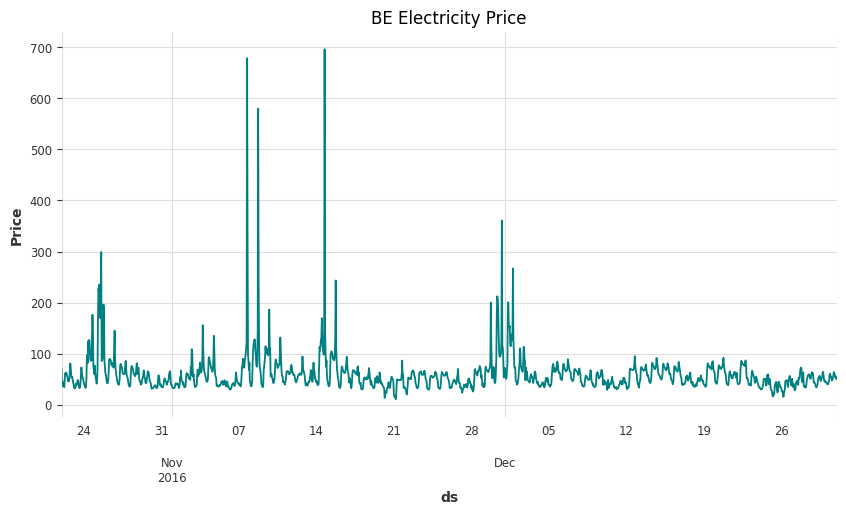

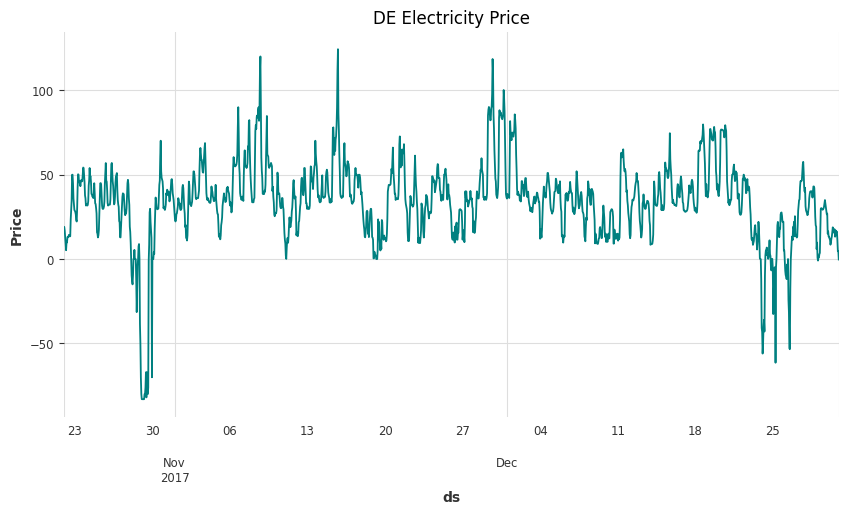

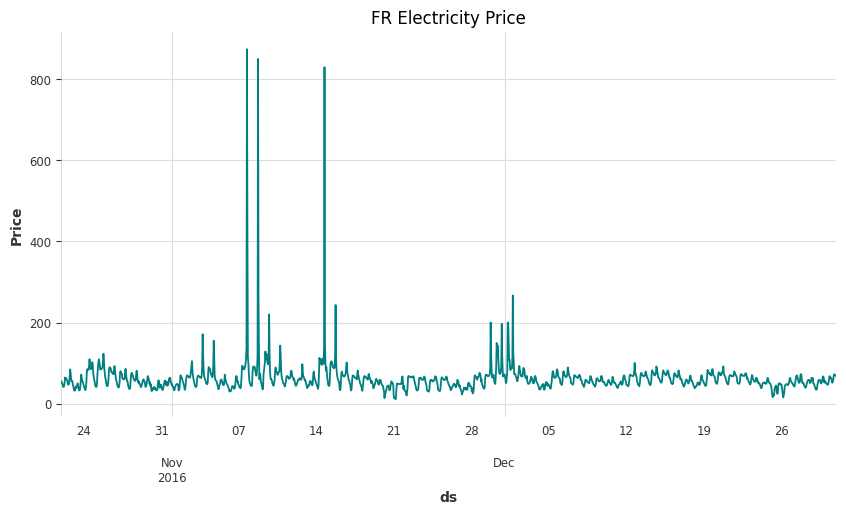

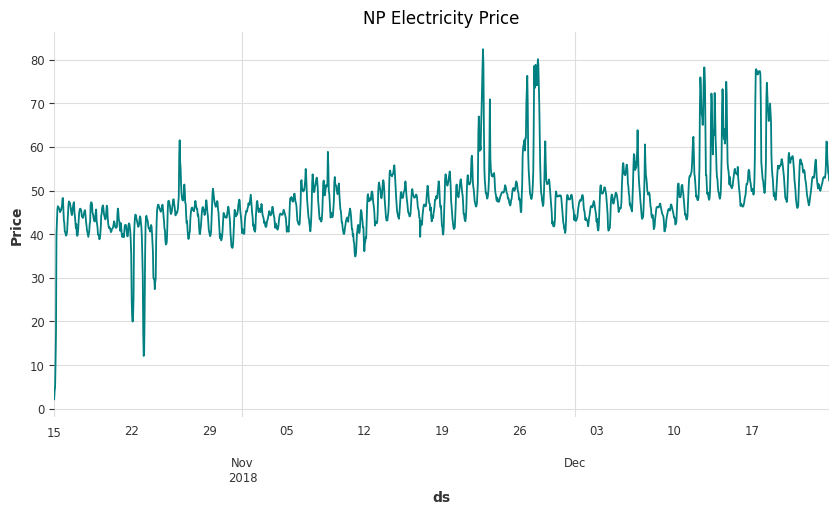

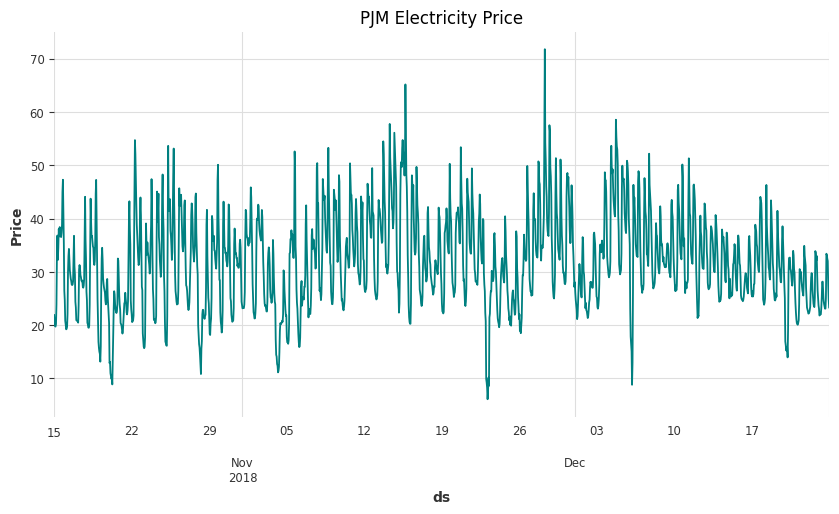

In [5]:
for country in df.unique_id.unique():
  plt.figure(figsize=(10,5))
  df[df['unique_id']==country].y.plot(title=f'{country} Electricity Price', color='teal')
  plt.ylabel('Price')
  plt.show()


Subset df for only $[BE,DE]$

In [6]:
df = df[df['unique_id'].isin(['NP','PJM'])]
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2018-10-15 00:00:00,NP,2.17,34078.0,1791.0
2018-10-15 01:00:00,NP,4.03,33469.0,1489.0
2018-10-15 02:00:00,NP,4.88,33313.0,1233.0
2018-10-15 03:00:00,NP,10.47,33535.0,1035.0
2018-10-15 04:00:00,NP,17.51,34267.0,854.0


Get plots of electricity prices on same plot.

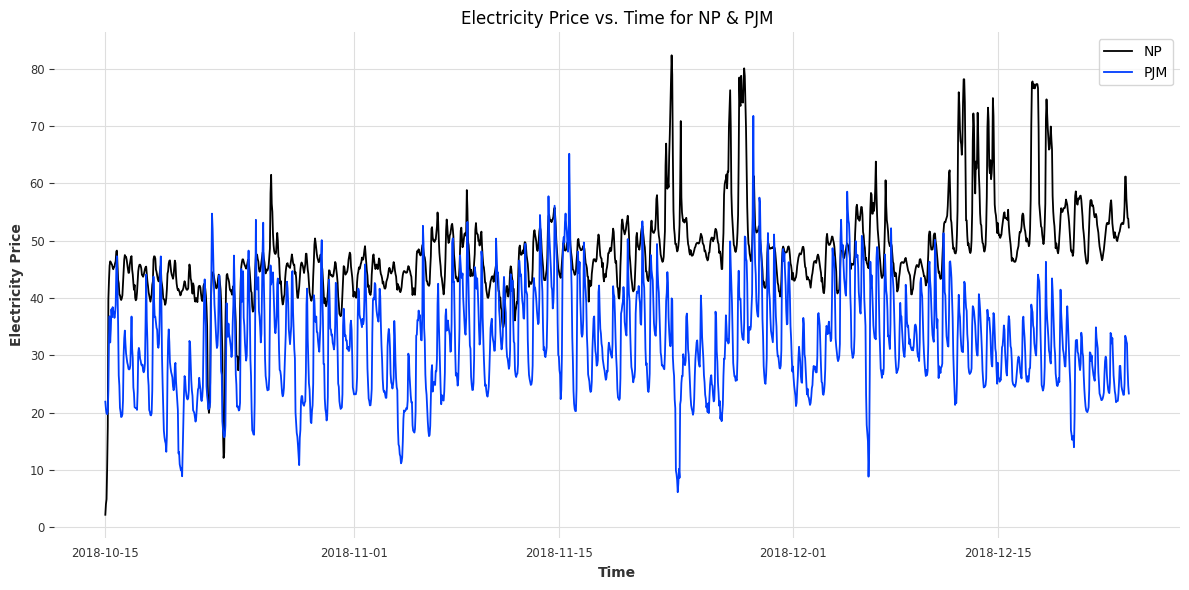

In [7]:
# Group by 'unique_id' and plot each group

plt.figure(figsize=(12, 6))
for uid, group in df.groupby('unique_id'):
    plt.plot(group.index, group['y'], label=str(uid))

plt.xlabel('Time')
plt.ylabel('Electricity Price')
plt.title('Electricity Price vs. Time for NP & PJM')
plt.legend(frameon=True)
plt.grid(True)
plt.tight_layout()
plt.show()

Separate time series into two dataframes for further analysis.

In [8]:
df_NP = df[df['unique_id']=='NP']
df_PJM = df[df['unique_id']=='PJM']

In [9]:
# Seasonal Decomposition Function

def seasonal_decomposition(series,model,period):
  result = seasonal_decompose(series, model=model, period=period)
  fig = result.plot()
  fig.set_figheight(8)
  fig.set_figwidth(12)
  plt.show()
  return

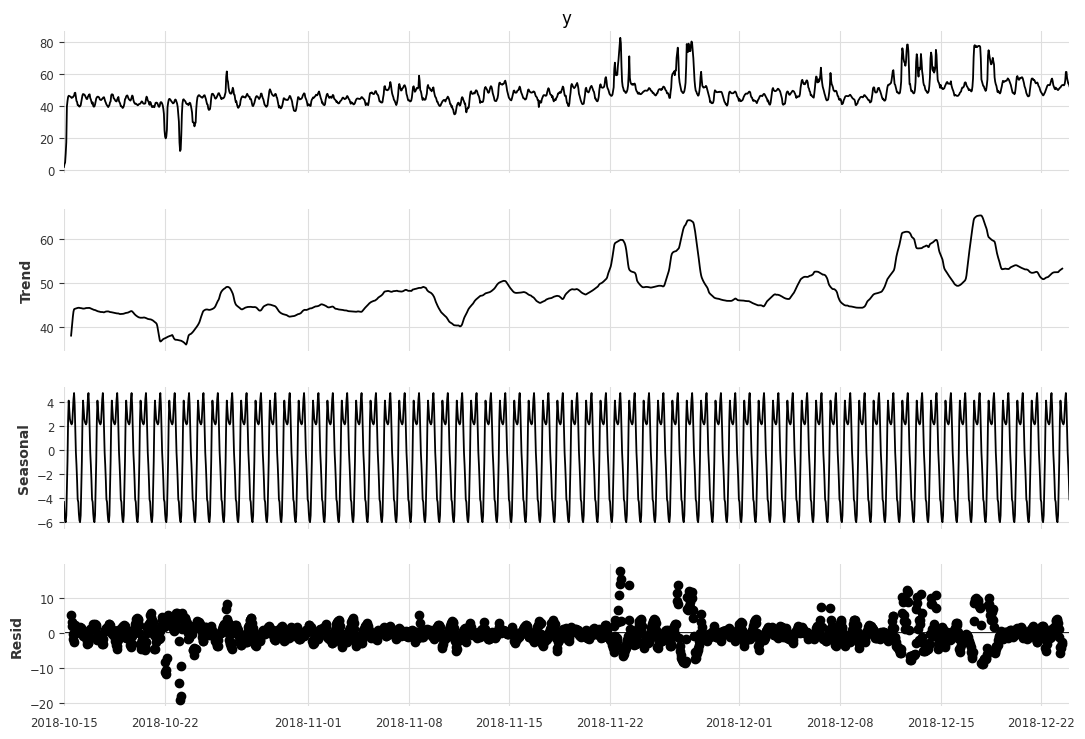

In [10]:
seasonal_decomposition(df_NP['y'],model='additive',period=24)

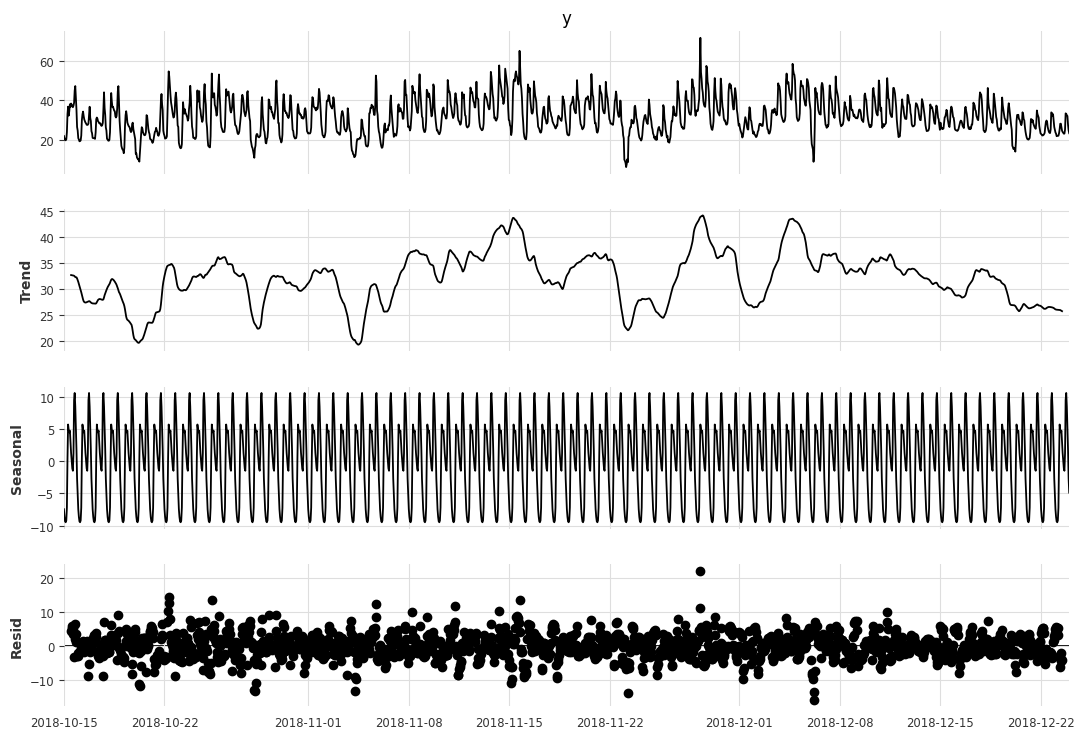

In [11]:
seasonal_decomposition(df_PJM['y'],model='additive',period=24)

## ACF and PACF

In [12]:
# Plot the ACF for the electricity pricing data

def plot_acf_pacf(series, lags, color, plot_variable):

  fig, ax = plt.subplots(figsize=(15,7))
  plot_acf(series, lags=lags, ax=ax, color=color)
  plt.title(f"ACF of {plot_variable}")
  plt.show()

  fig, ax = plt.subplots(figsize=(15,7))
  plot_pacf(series, lags=lags, ax=ax, color=color)
  plt.title(f"PACF of {plot_variable}")
  plt.show()
  return

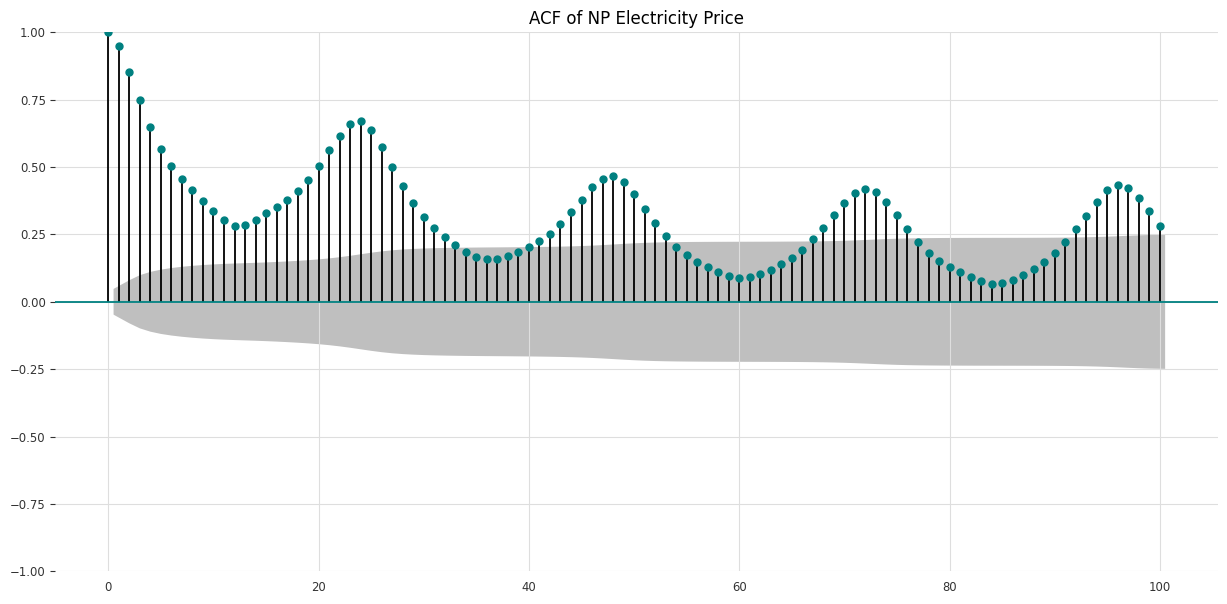

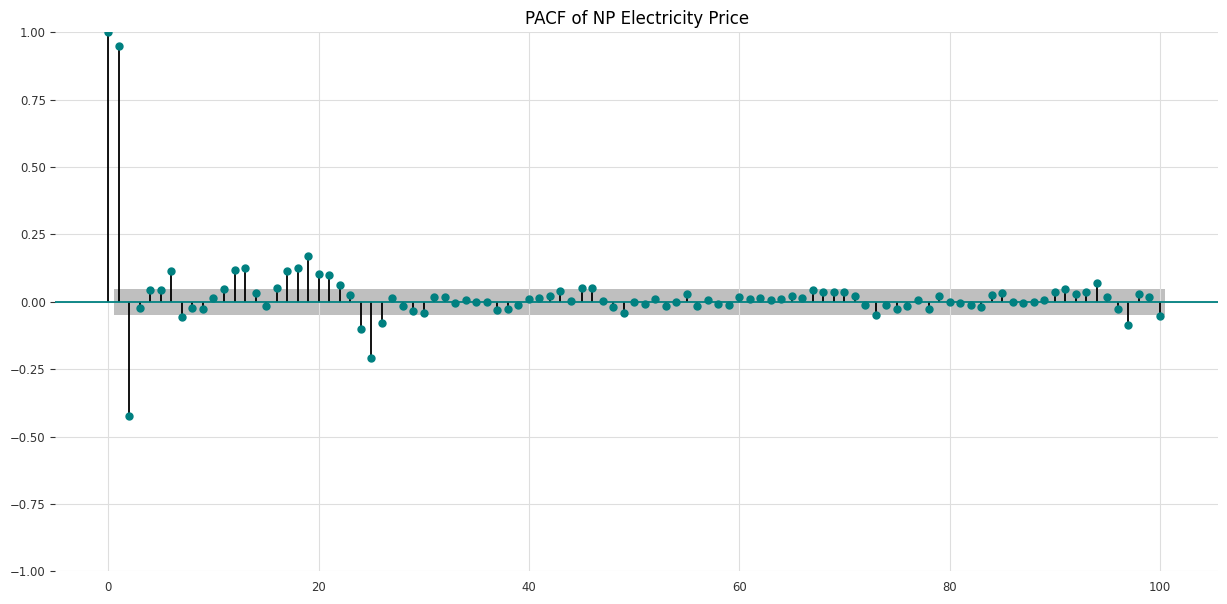

In [13]:
plot_acf_pacf(df_NP['y'], lags=100, color='teal', plot_variable='NP Electricity Price')

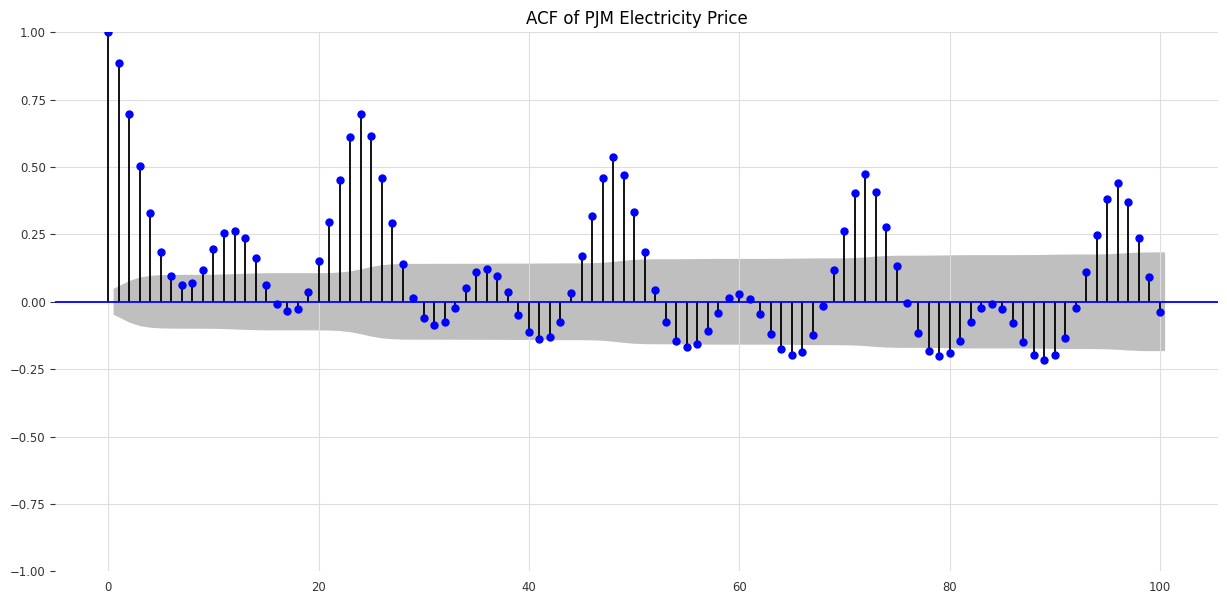

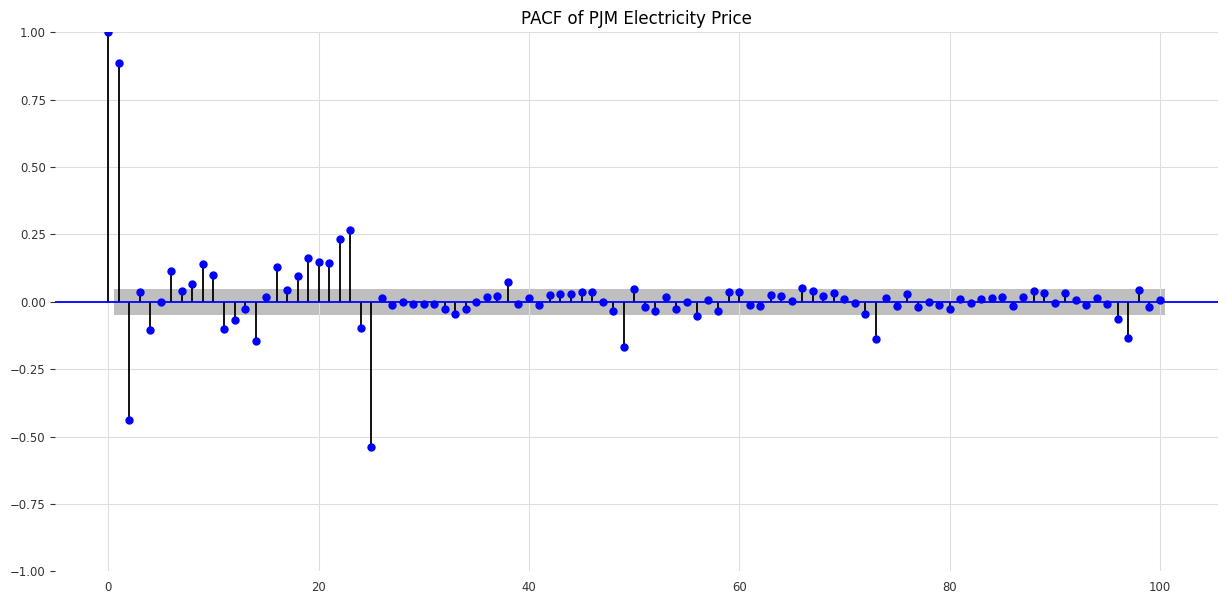

In [14]:
plot_acf_pacf(df_PJM['y'], lags=100, color='blue', plot_variable='PJM Electricity Price')

## Stationarity

In [15]:
def adf_test(series, title=None):

  # Run the ADF test
  result = adfuller(series.dropna(), autolag='AIC')

  # Extract and print results
  print('ADF Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print(f'   {key}: {value}')

  # Interpretation
  if result[1] < 0.05:
      print("Result: The series is likely stationary (reject H0).")
  else:
      print("Result: The series is likely non-stationary (fail to reject H0).")

In [16]:
adf_test(df_NP['y'])

ADF Statistic: -3.3554913300195155
p-value: 0.012573042885150012
Critical Values:
   1%: -3.4343097809950986
   5%: -2.8632890172254655
   10%: -2.5677011356149544
Result: The series is likely stationary (reject H0).


In [17]:
adf_test(df_PJM['y'])

ADF Statistic: -4.642934131061114
p-value: 0.00010757140301597731
Critical Values:
   1%: -3.4343073846517536
   5%: -2.863287959472204
   10%: -2.5677005723752067
Result: The series is likely stationary (reject H0).


## Create a dataframe of the two time series with a common timestamp index.

In [18]:
# Prepare dataframes for concatenation

df_NP = df_NP.rename(columns={'y':'y_NP','Exogenous1':'Exogenous1_NP','Exogenous2':'Exogenous2_NP'})
df_NP = df_NP.drop(columns=['unique_id'])
df_PJM = df_PJM.rename(columns={'y':'y_PJM','Exogenous1':'Exogenous1_PJM','Exogenous2':'Exogenous2_PJM'})
df_PJM = df_PJM.drop(columns=['unique_id'])
df_joined_past = pd.concat([df_NP, df_PJM],axis=1)
df_joined_past.head()

,y_NP,Exogenous1_NP,Exogenous2_NP,y_PJM,Exogenous1_PJM,Exogenous2_PJM
ds,,,,,,
2018-10-15 00:00:00,2.17,34078.0,1791.0,21.911758,66998.0,8704.0
2018-10-15 01:00:00,4.03,33469.0,1489.0,20.657265,65025.0,8438.0
2018-10-15 02:00:00,4.88,33313.0,1233.0,19.825215,64091.0,8283.0
2018-10-15 03:00:00,10.47,33535.0,1035.0,19.741627,64113.0,8233.0
2018-10-15 04:00:00,17.51,34267.0,854.0,20.212269,65594.0,8284.0


In [19]:
# Prepare the times-series object

series = TimeSeries.from_dataframe(df_joined_past,
                                   value_cols = ['y_NP','y_PJM'],
                                   fill_missing_dates=True,
                                   freq='H'
                                   # static_covariates=,
                                   )

series

<TimeSeries (ds: 1680, component: 2, sample: 1)> Size: 27kB
array([[[ 2.17    ],
        [21.911758]],

       [[ 4.03    ],
        [20.657265]],

       [[ 4.88    ],
        [19.825215]],

       ...,

       [[53.99    ],
        [27.632347]],

       [[53.86    ],
        [24.746053]],

       [[52.32    ],
        [23.333499]]])
Coordinates:
  * ds         (ds) datetime64[ns] 13kB 2018-10-15 ... 2018-12-23T23:00:00
  * component  (component) object 16B 'y_NP' 'y_PJM'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [20]:
# Create past covariate series for each target
past_covariates = TimeSeries.from_dataframe(df_joined_past, value_cols=['Exogenous1_NP', 'Exogenous2_NP', 'Exogenous1_PJM', 'Exogenous2_PJM'])
past_covariates

<TimeSeries (ds: 1680, component: 4, sample: 1)> Size: 54kB
array([[[34078.],
        [ 1791.],
        [66998.],
        [ 8704.]],

       [[33469.],
        [ 1489.],
        [65025.],
        [ 8438.]],

       [[33313.],
        [ 1233.],
        [64091.],
        [ 8283.]],

       ...,

       [[55990.],
        [  478.],
        [94319.],
        [11433.]],

       [[54336.],
        [  410.],
        [90106.],
        [11108.]],

       [[51679.],
        [  371.],
        [85547.],
        [10581.]]])
Coordinates:
  * ds         (ds) datetime64[ns] 13kB 2018-10-15 ... 2018-12-23T23:00:00
  * component  (component) object 32B 'Exogenous1_NP' ... 'Exogenous2_PJM'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [21]:
# Time as an Encoder - the idea is to convert 'Year' to a small value for further processing

def encode_year(idx):
  return (idx.year-2000)/50  # 2000 and 50 are arbitrarily-chosen numbers

In [22]:
# Set up the 'add_encoders' dictionary

add_encoders = {
    'cyclic': {'future': ['hour','day','dayofweek','week','month']},
    'datetime_attribute': {'future': ['hour','day','dayofweek','week','month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom' : {'past': [encode_year], 'future': [encode_year]},
    'transformer': Scaler(),
    'tz': 'CET'
    }


## Past Covariates

## Future Covariates

In [23]:
# Read in the future dataset

df_future = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /TFT/electricity-future.csv',
                index_col='ds',parse_dates=True)
df_future.head()

,unique_id,Exogenous1,Exogenous2
ds,,,
2016-12-31 00:00:00,BE,64108.0,70318.0
2016-12-31 01:00:00,BE,62492.0,67898.0
2016-12-31 02:00:00,BE,61571.0,68379.0
2016-12-31 03:00:00,BE,60381.0,64972.0
2016-12-31 04:00:00,BE,60298.0,62900.0


In [24]:
df_future.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2016-12-31 00:00:00 to 2018-12-24 23:00:00
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   120 non-null    object 
 1   Exogenous1  120 non-null    float64
 2   Exogenous2  120 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.8+ KB


In [25]:
def process_future_df(df,unique_ids):

  df = df[df['unique_id'].isin(unique_ids)].copy() # Added .copy() to avoid SettingWithCopyWarning
  separated_dfs = {}
  for id in unique_ids:
    separated_dfs[f"df_future_{id}"] = df[df['unique_id']==id]
    separated_dfs[f"df_future_{id}"] = separated_dfs[f"df_future_{id}"].drop(columns=['unique_id'])
    separated_dfs[f"df_future_{id}"] = separated_dfs[f"df_future_{id}"].rename(columns={'Exogenous1': f'Exogenous1_{id}','Exogenous2':f'Exogenous2_{id}'})
  df_joined_future = pd.concat(separated_dfs.values(),axis=1)

  return df_joined_future


In [26]:
df_joined_future = process_future_df(df_future,['NP','PJM'])
df_joined_future.head()

,Exogenous1_NP,Exogenous2_NP,Exogenous1_PJM,Exogenous2_PJM
ds,,,,
2018-12-24 00:00:00,49119.0,461.0,84069.0,10276.0
2018-12-24 01:00:00,48115.0,484.0,81849.0,9809.0
2018-12-24 02:00:00,47727.0,497.0,80671.0,9501.0
2018-12-24 03:00:00,47673.0,509.0,80229.0,9337.0
2018-12-24 04:00:00,47848.0,510.0,80734.0,9283.0


In [27]:
X_past = df_joined_past.copy()
X_past.head()

,y_NP,Exogenous1_NP,Exogenous2_NP,y_PJM,Exogenous1_PJM,Exogenous2_PJM
ds,,,,,,
2018-10-15 00:00:00,2.17,34078.0,1791.0,21.911758,66998.0,8704.0
2018-10-15 01:00:00,4.03,33469.0,1489.0,20.657265,65025.0,8438.0
2018-10-15 02:00:00,4.88,33313.0,1233.0,19.825215,64091.0,8283.0
2018-10-15 03:00:00,10.47,33535.0,1035.0,19.741627,64113.0,8233.0
2018-10-15 04:00:00,17.51,34267.0,854.0,20.212269,65594.0,8284.0


In [28]:
X_past = X_past.drop(columns=['y_NP','y_PJM'])
X_past.head()

,Exogenous1_NP,Exogenous2_NP,Exogenous1_PJM,Exogenous2_PJM
ds,,,,
2018-10-15 00:00:00,34078.0,1791.0,66998.0,8704.0
2018-10-15 01:00:00,33469.0,1489.0,65025.0,8438.0
2018-10-15 02:00:00,33313.0,1233.0,64091.0,8283.0
2018-10-15 03:00:00,33535.0,1035.0,64113.0,8233.0
2018-10-15 04:00:00,34267.0,854.0,65594.0,8284.0


In [29]:
X_future = df_joined_future.copy()
X_future.head()

,Exogenous1_NP,Exogenous2_NP,Exogenous1_PJM,Exogenous2_PJM
ds,,,,
2018-12-24 00:00:00,49119.0,461.0,84069.0,10276.0
2018-12-24 01:00:00,48115.0,484.0,81849.0,9809.0
2018-12-24 02:00:00,47727.0,497.0,80671.0,9501.0
2018-12-24 03:00:00,47673.0,509.0,80229.0,9337.0
2018-12-24 04:00:00,47848.0,510.0,80734.0,9283.0


In [30]:
X = pd.concat([X_past, X_future])
X.head()

,Exogenous1_NP,Exogenous2_NP,Exogenous1_PJM,Exogenous2_PJM
ds,,,,
2018-10-15 00:00:00,34078.0,1791.0,66998.0,8704.0
2018-10-15 01:00:00,33469.0,1489.0,65025.0,8438.0
2018-10-15 02:00:00,33313.0,1233.0,64091.0,8283.0
2018-10-15 03:00:00,33535.0,1035.0,64113.0,8233.0
2018-10-15 04:00:00,34267.0,854.0,65594.0,8284.0


In [31]:
X.tail()

,Exogenous1_NP,Exogenous2_NP,Exogenous1_PJM,Exogenous2_PJM
ds,,,,
2018-12-24 19:00:00,52591.0,2544.0,94939.0,11246.0
2018-12-24 20:00:00,51787.0,2785.0,94035.0,11070.0
2018-12-24 21:00:00,51488.0,2919.0,92923.0,10963.0
2018-12-24 22:00:00,50928.0,3119.0,90970.0,10802.0
2018-12-24 23:00:00,49889.0,3306.0,88037.0,10419.0


In [32]:
future_covariates = TimeSeries.from_dataframe(X)
future_covariates

<TimeSeries (ds: 1704, component: 4, sample: 1)> Size: 55kB
array([[[34078.],
        [ 1791.],
        [66998.],
        [ 8704.]],

       [[33469.],
        [ 1489.],
        [65025.],
        [ 8438.]],

       [[33313.],
        [ 1233.],
        [64091.],
        [ 8283.]],

       ...,

       [[51488.],
        [ 2919.],
        [92923.],
        [10963.]],

       [[50928.],
        [ 3119.],
        [90970.],
        [10802.]],

       [[49889.],
        [ 3306.],
        [88037.],
        [10419.]]])
Coordinates:
  * ds         (ds) datetime64[ns] 14kB 2018-10-15 ... 2018-12-24T23:00:00
  * component  (component) object 32B 'Exogenous1_NP' ... 'Exogenous2_PJM'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

## Scaling

In [33]:
# Two scalers: one for the series, one for the covariates

scaler1 = Scaler()
scaler2 = Scaler()

y_transformed = scaler1.fit_transform(series)
past_covariates_transformed = scaler2.fit_transform(past_covariates)
future_covariates_transformed = scaler2.transform(future_covariates)

## TFT Model Parameters

* `input_chunk_length`: 96 hours
* `output_chunk_length` or `forecast_horizon`: 24 hours
* `hidden_size`: 16
* `LSTM_layers`: 2
* `num_attention_heads`: 4
* `dropout_rate`: 0.1
* `batch_size`: 64
* `n_epochs`: 10
* `use_static_covariates`=`True`




In [34]:
# Set forecast horizon

forecast_horizon = 24

In [35]:
# Build and fit the TFT model

tft = TFTModel(input_chunk_length=96,
               output_chunk_length=forecast_horizon,
               add_encoders=add_encoders,
               hidden_size=16,
               lstm_layers=2,
               num_attention_heads=4,
               dropout=0.1,
               batch_size=64,
               n_epochs=10,
               use_static_covariates=True,
               pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]},
               random_state=42,
               )

tft.fit(y_transformed,
        past_covariates=past_covariates_transformed,
        future_covariates=future_covariates_transformed,
        )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=96, output_chunk_length=24, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x7c9eb2b5a340>], 'future': [<function encode_year at 0x7c9eb2b5a340>]}, 'transformer': Scaler, 'tz': 'CET'}, batch_size=64, n_epochs=10, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, random_state=42)

## Cross Validation

In [38]:
cv = tft.historical_forecasts(
    series=series,
    past_covariates=past_covariates_transformed,
    future_covariates=future_covariates_transformed,
    forecast_horizon=forecast_horizon,
    start=len(series) - 10*forecast_horizon,
    stride=forecast_horizon,
    retrain=True,
    last_points_only=False
    )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [39]:
cv

[<TimeSeries (ds: 24, component: 2, sample: 1)> Size: 384B
 array([[[4.55319919],
         [6.13286541]],
 
        [[6.14951609],
         [7.02169568]],
 
        [[6.71492355],
         [6.33259277]],
 
        [[7.31332262],
         [7.08217635]],
 
        [[7.46774129],
         [6.72061188]],
 
        [[5.9645851 ],
         [4.91368902]],
 
        [[7.85160012],
         [7.54773898]],
 ...
        [[7.46769278],
         [6.29005008]],
 
        [[6.8376512 ],
         [6.08161316]],
 
        [[7.47738212],
         [7.05756184]],
 
        [[7.90386646],
         [6.20367606]],
 
        [[5.7425991 ],
         [6.38563633]],
 
        [[5.81236408],
         [6.3299343 ]],
 
        [[6.89822936],
         [6.57527719]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 192B 2018-12-14 ... 2018-12-14T23:00:00
   * component  (component) object 16B 'y_NP' 'y_PJM'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  None
     hierarchy:          N

In [40]:
rsme_cv = []

for i in range(len(cv)):
  predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))

  # Determine date range for actuals
  start = predictions.index.min()
  end = predictions.index.max()
  actuals = df.y[start:end]

  # Calculate RMSE
  error_cv = root_mean_squared_error(actuals, predictions)
  rsme_cv.append(error_cv)

print(f"The mean cv RMSE is: {np.mean(rsme_cv)}")
print(f"The values of cv RMSE are: {rsme_cv}")

ERROR:darts.timeseries:AssertionError: Only univariate TimeSeries instances support this method


AssertionError: Only univariate TimeSeries instances support this method

## Visualize the predictions

In [ ]:
fig,ax = plt.subplots(figsize=(15,7))

# Plot the actuals

for i in range(len(cv)):
  predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))

  # Determine date range for actuals
  start = predictions.index.min()
  end = predictions.index.max()
  actuals = df.y[start:end]

  ax.plot(actuals, label='Actuals')
  ax.plot(predictions, label='Predictions', linestyle='dashed')

  ax.set_xlabel('Time')
  ax.set_ylabel('Electricity Price')
  ax.set_title('TFT Cross Validation Results')
  ax.legend()

plt.show()

## Parameter Tuning

We will perform `ParameterSampler` tuning

In [ ]:
from sklearn.model_selection import ParameterSampler

# Parameter Grid

param_grid = {
    'input_chunk_length': [48,96, 172],
    'output_chunk_length': [24],
    'hidden_size': [8, 16, 24],
    'num_attention_heads': [2,4,6],
    'dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64, 128],
    'lstm_layers': [1,2,4],
    'n_epochs': [5,10,20]
}

# Number of parameter combinations to try
n_iter=10

# Generate a list of parameter combinations to sample from the parameter grid
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))

# Duplicate the parameter list for further use or comparison
param_list2 = param_list

# Print the list of parameter combinations
print(param_list)

In [ ]:
# Define fixed parameters that will be used across all configurations

fixed_params = {
    'use_static_covariates': True,
    'add_encoders': add_encoders,
    'pl_trainer_kwargs': {'accelerator': 'gpu', "devices": [0]},
    }

# Update each parameter set in the list with the fixed parameters using the '.update()' function
for params in param_list:
  params.update(fixed_params)

In [ ]:
# Check the params list
param_list

In [ ]:
# Initialize a list to store RMSE values for each set of parameters
rmse = []

# Iterate over each set of parameter combinations
for params in param_list:
  # Build the TFT model using the current set of parameters
  model = TFTModel(**params)

  # Perform cross-validation with rolling forecast
  cv = model.historical_forecasts(
      series = y_transformed,
      past_covariates = past_covariates_transformed,
      future_covariates = future_covariates_transformed,
      forecast_horizon=forecast_horizon,  # Number of time steps to forecast
      start=df.shape[0] - 10 * forecast_horizon,  # Start point for the rolling forecast
      retrain=True,  # Whether to retrain the model at each step
      stride=forecast_horizon,  # Number of time steps to move forward for each forecast
      last_points_only=False  # Whether to include only the last points in each rolling window
  )

  # Initialize a list to store RMSE values for each fold
  rmse_cv = []

  # Iterate over each fold in the cross-validation results
  for i in range(len(cv)):
    # Get the predictions from the current fold and inverse transform to the original scale
    predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))

    # Extract the corresponding actual values
    start = predictions.index.min()
    end = predictions.index.max()
    actuals = df.y[start:end]

    # Compute the RMSE for the current fold
    error_cv = np.sqrt(mean_squared_error(actuals, predictions))
    rmse_cv.append(error_cv)

  # Compute the average RMSE for the current set of parameters and append to the list
  rmse.append(np.mean(rmse_cv))

  # Print the parameters tested and the corresponding RMSE
  print(f"Tested parameters: {params} => RMSE {np.mean(rmse_cv)}")

In [ ]:
# Create a DataFrame and add the RMSE values
results_df = pd.DataFrame(param_list2)
results_df['rmse'] = rmse
results_df

In [ ]:
# Identify the parameter set(s) with the lowest RMSE and export it to a CSV file
best_params = results_df[results_df['rmse'] == results_df['rmse'].min()]
best_params.to_csv('best_params.csv')

## Predict the Future

In [ ]:
# Load the best parameters from the CSV file, and put it in a dictionary
best_params = pd.read_csv('best_params.csv', index_col =0).drop(columns = "rmse")
best_params_dict = best_params.squeeze().to_dict()
best_params_dict

In [ ]:
# List of parameters that should be converted to integers
int_params = ['input_chunk_length', 'output_chunk_length',
              'hidden_size', 'num_attention_heads', 'batch_size',
              'lstm_layers', 'n_epochs']

# Convert specified float parameters to integers
for key in int_params:
  best_params_dict[key] = int(best_params_dict[key])

In [ ]:
# Update the best parameters dictionary with the fixed parameters
best_params_dict.update(fixed_params)
best_params_dict

In [ ]:
# Build the TFT model using the best-tuned parameters
tuned_tft = TFTModel(**best_params_dict)

# Fit the tuned model
tuned_tft.fit(y_transformed,
                past_covariates = past_covariates_transformed,
                future_covariates = future_covariates_transformed)

In [ ]:
# Generate forecasts for the future using the tuned model
forecast = tuned_tft.predict(n = forecast_horizon,
                               series = y_transformed,
                               past_covariates = past_covariates_transformed,
                               future_covariates = future_covariates_transformed)

# Inverse transform the forecasted values to the original scale and rename the series
forecast = TimeSeries.to_series(scaler1.inverse_transform(forecast)).rename("TFT")
# Display the forecasted values
forecast

In [ ]:
# Plot the forecasted values along with actual data

# Set figure size
fig, ax = plt.subplots(figsize = (10,6))
# Plot actual values from December 2017 onwards
ax.plot(df.y['2017-12-25':], label = "actuals")
# Plot forecasted values with a dashed line
ax.plot(forecast, label = "forecast", linestyle = 'dashed')

# Set labels, title, and legend for the plot
ax.set_xlabel("Time")
ax.set_ylabel("Hourly Electricity Price")
ax.set_title("TFT Forecast")
ax.legend()
plt.show()

## Interpretability

In [ ]:
from darts.explainability import TFTExplainer

In [ ]:
# Build the explainer for the tuned TFT model
explainer = TFTExplainer(tuned_tft)
# Generate explainability results for the model
explainability_result = explainer.explain()

In [ ]:
# Plot the variable importance based on the explainability results
explainer.plot_variable_selection(explainability_result, fig_size = (15,15))

In [ ]:
# Plot the attention mechanism for the model
explainer.plot_attention(explainability_result, plot_type = "time")

In [ ]:
# Prepare past and future covariates for historical forecasting

# Past covariates should have the same length as the series used for training
past_covariates_hf = TimeSeries.from_dataframe(df_joined_past.drop(columns=['y_NP', 'y_PJM']))
past_covariates_transformed_hf = scaler2.transform(past_covariates_hf)

# Future covariates should cover the entire historical period plus the forecast horizon
# This allows darts to select the appropriate future covariates for each historical forecast step
future_covariates_hf = TimeSeries.from_dataframe(X)
future_covariates_transformed_hf = scaler2.transform(future_covariates_hf)

In [ ]:
# Build and fit the TFT model

tft = TFTModel(input_chunk_length=96,
               output_chunk_length=forecast_horizon,
               add_encoders=add_encoders,
               hidden_size=16,
               lstm_layers=2,
               num_attention_heads=4,
               dropout=0.1,
               batch_size=64,
               n_epochs=10,
               use_static_covariates=True,
               pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]},
               random_state=42,
               )

tft.fit(y_transformed,
        past_covariates=past_covariates_transformed_hf,
        future_covariates=future_covariates_transformed_hf,
        )

In [ ]:
cv = tft.historical_forecasts(
    series=y_transformed,
    past_covariates=past_covariates_transformed_hf,
    future_covariates=future_covariates_transformed_hf,
    forecast_horizon=forecast_horizon,
    start=len(series) - 10*forecast_horizon,
    stride=forecast_horizon,
    retrain=True,
    last_points_only=False
    )